<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Eco_Driving_Behavior_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eco-Driving Behavior Dataset

# Introduction and Insights

---

**A Deep Dive into Eco-Driving Telematics**

The Dataset The Eco-Driving Behavior Dataset serves as a digital window into the physics of driver efficiency. Comprising granular telematics data—including acceleration_smoothness, rpm_variation, harsh_braking_count, idling_time, and fuel_consumption—it allows us to quantify exactly what distinguishes a "Good Driver" from a "Bad Driver." The target variable, eco_score, acts as the ultimate truth, summarizing complex driving patterns into a single metric of efficiency.

Exploratory Insights Our initial statistical analysis revealed that efficiency is not random; it is highly structural. We observed strong negative correlations between harsh_braking_count and the eco_score, proving that reactive driving (braking hard) is one of the most significant detractors from fuel economy. Furthermore, the data highlighted the "Silent Killer" of efficiency: idling_time. While often overlooked by drivers who focus on speed, the data suggests that time spent stationary with the engine running disproportionately impacts the final score.

Advanced Segmentation Moving beyond simple averages, we utilized Unsupervised Learning (K-Means Clustering) to identify distinct "Driver Personas." The data naturally segmented into groups: the "Aggressive Speedsters" (characterized by high RPM variation and low smoothness), the "Eco-Warriors" (consistent smoothness, low idling), and the "Average Commuters." Principal Component Analysis (PCA) further confirmed this structure, visualizing the "Driving Universe" as a 2D map where efficient and inefficient behaviors occupied distinctly separate regions, validating that these behaviors are fundamentally different physical states.

Predictive Modeling & Business Impact The pinnacle of the analysis was the construction of a Random Forest Regressor. By training an AI model on the behavioral features, we successfully predicted the eco_score with high accuracy. More importantly, the Feature Importance analysis answered the critical "Why?" question. It revealed that acceleration_smoothness and idling_time were often the primary drivers of the score.

Conclusion This project transforms raw sensor data into actionable business intelligence. For fleet managers or insurance companies, the takeaway is clear: efficiency is not improved by general advice like "drive slower." It is improved by targeting specific, measurable behaviors—specifically reducing idle time and smoothing out acceleration inputs. This data-driven approach moves fleet management from intuition to precision engineering.


---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d sonalshinde123/eco-driving-behavior-dataset

# Unziping the downloaded file
!unzip eco-driving-behavior-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/sonalshinde123/eco-driving-behavior-dataset
License(s): CC0-1.0
  0% 0.00/299k [00:00<?, ?B/s]
100% 299k/299k [00:00<00:00, 684MB/s]
Archive:  eco-driving-behavior-dataset.zip
  inflating: eco_driving_score.csv   


# Data Inspection

In [5]:
df = pd.read_csv('eco_driving_score.csv')
df.head(11)

,rpm_variation,harsh_braking_count,idling_time,fuel_consumption,acceleration_smoothness,eco_score
0,2147,5,14.2,7.87,0.97,42.1
1,1703,3,4.2,9.37,0.50,36.1
2,2253,0,5.5,8.85,0.78,49.8
3,2866,3,21.7,5.87,0.60,27.7
4,1636,2,3.1,6.71,0.99,79.4
5,1636,2,0.0,8.33,0.24,41.3
6,2905,4,18.5,8.06,0.67,29.6
7,2337,4,12.2,9.25,0.54,28.5
8,1471,2,13.3,8.36,0.87,55.0
9,2179,2,14.8,8.59,0.46,27.7


In [6]:
df.tail(11)

,rpm_variation,harsh_braking_count,idling_time,fuel_consumption,acceleration_smoothness,eco_score
29989,2922,1,4.1,8.36,0.70,49.7
29990,1647,2,5.9,5.27,0.74,79.8
29991,3077,4,5.3,10.71,0.84,31.1
29992,2413,2,9.4,9.74,0.63,29.1
29993,937,4,18.3,7.55,0.87,54.0
29994,917,3,10.6,6.28,0.72,69.9
29995,1395,0,6.5,6.50,0.76,74.8
29996,2811,5,6.8,6.84,0.57,38.7
29997,1449,6,15.3,9.93,0.67,33.7
29998,500,3,1.0,6.20,0.73,88.3


In [7]:
df.shape

(30000, 6)

In [8]:
df.columns

Index(['rpm_variation', 'harsh_braking_count', 'idling_time',
       'fuel_consumption', 'acceleration_smoothness', 'eco_score'],
      dtype='object')

In [9]:
df.dtypes

,0
rpm_variation,int64
harsh_braking_count,int64
idling_time,float64
fuel_consumption,float64
acceleration_smoothness,float64
eco_score,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rpm_variation            30000 non-null  int64  
 1   harsh_braking_count      30000 non-null  int64  
 2   idling_time              30000 non-null  float64
 3   fuel_consumption         30000 non-null  float64
 4   acceleration_smoothness  30000 non-null  float64
 5   eco_score                30000 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 1.4 MB


In [11]:
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
rpm_variation,30000.0,1807.951133,679.423972,500.00,1325.00,1801.00,2272.00,4935.00
harsh_braking_count,30000.0,2.725667,1.671038,0.00,2.00,3.00,4.00,14.00
idling_time,30000.0,11.281750,5.294333,0.00,7.60,11.20,14.90,32.50
fuel_consumption,30000.0,8.052019,1.512837,3.50,7.03,8.04,9.05,14.43
acceleration_smoothness,30000.0,0.667652,0.155482,0.03,0.56,0.67,0.78,1.00
eco_score,30000.0,47.488843,19.462413,0.00,34.60,48.40,61.30,100.00


In [12]:
df.isnull().sum()

,0
rpm_variation,0
harsh_braking_count,0
idling_time,0
fuel_consumption,0
acceleration_smoothness,0
eco_score,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Outliers

In [14]:
Q1 = df['eco_score'].quantile(0.25)
Q3 = df['eco_score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['eco_score'] >= lower_bound) | (df['eco_score'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 30000
Shape after outlier handling: 30000


# Statistics Analysis

In [21]:
import scipy.stats as stats

# --- A. Correlation Analysis ---
corr_matrix = df.corr(numeric_only=True)

print("--- Correlation Matrix (Eco Score vs other features) ---")
print(corr_matrix['eco_score'].sort_values(ascending=False))


--- Correlation Matrix (Eco Score vs other features) ---
eco_score                  1.000000
acceleration_smoothness    0.481003
idling_time               -0.468010
rpm_variation             -0.537513
harsh_braking_count       -0.742530
fuel_consumption          -0.770575
Name: eco_score, dtype: float64


## Linear Regression Analysis


In [22]:
import statsmodels.api as sm

# Defining target and features
X = df.drop(columns=['eco_score'])
y = df['eco_score']

# Adding a constant (intercept) to the model
X_const = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X_const).fit()

# Printing the summary statistics
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              eco_score   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 8.185e+04
Date:                Sun, 18 Jan 2026   Prob (F-statistic):               0.00
Time:                        10:21:05   Log-Likelihood:                -91361.
No. Observations:               30000   AIC:                         1.827e+05
Df Residuals:                   29994   BIC:                         1.828e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

# T-Test with Binning


In [24]:
# create groups based on median fuel consumption
median_fuel = df['fuel_consumption'].median()

low_fuel_group = df[df['fuel_consumption'] <= median_fuel]['eco_score']
high_fuel_group = df[df['fuel_consumption'] > median_fuel]['eco_score']

# Perform T-Test
t_stat, p_val = stats.ttest_ind(low_fuel_group, high_fuel_group)

print(f"Median Fuel Consumption: {median_fuel}")
print(f"Mean Eco Score (Low Fuel Group): {low_fuel_group.mean():.2f}")
print(f"Mean Eco Score (High Fuel Group): {high_fuel_group.mean():.2f}")
print(f"\nT-Statistic: {t_stat:.4f}, P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("\n Conclusion: There is a statistically significant difference in Eco Scores between high and low fuel consumption groups.")
else:
    print("\n Conclusion: No significant difference found.")

Median Fuel Consumption: 8.04
Mean Eco Score (Low Fuel Group): 59.49
Mean Eco Score (High Fuel Group): 35.46

T-Statistic: 135.8606, P-Value: 0.0000e+00

 Conclusion: There is a statistically significant difference in Eco Scores between high and low fuel consumption groups.


# Univariate Analysis

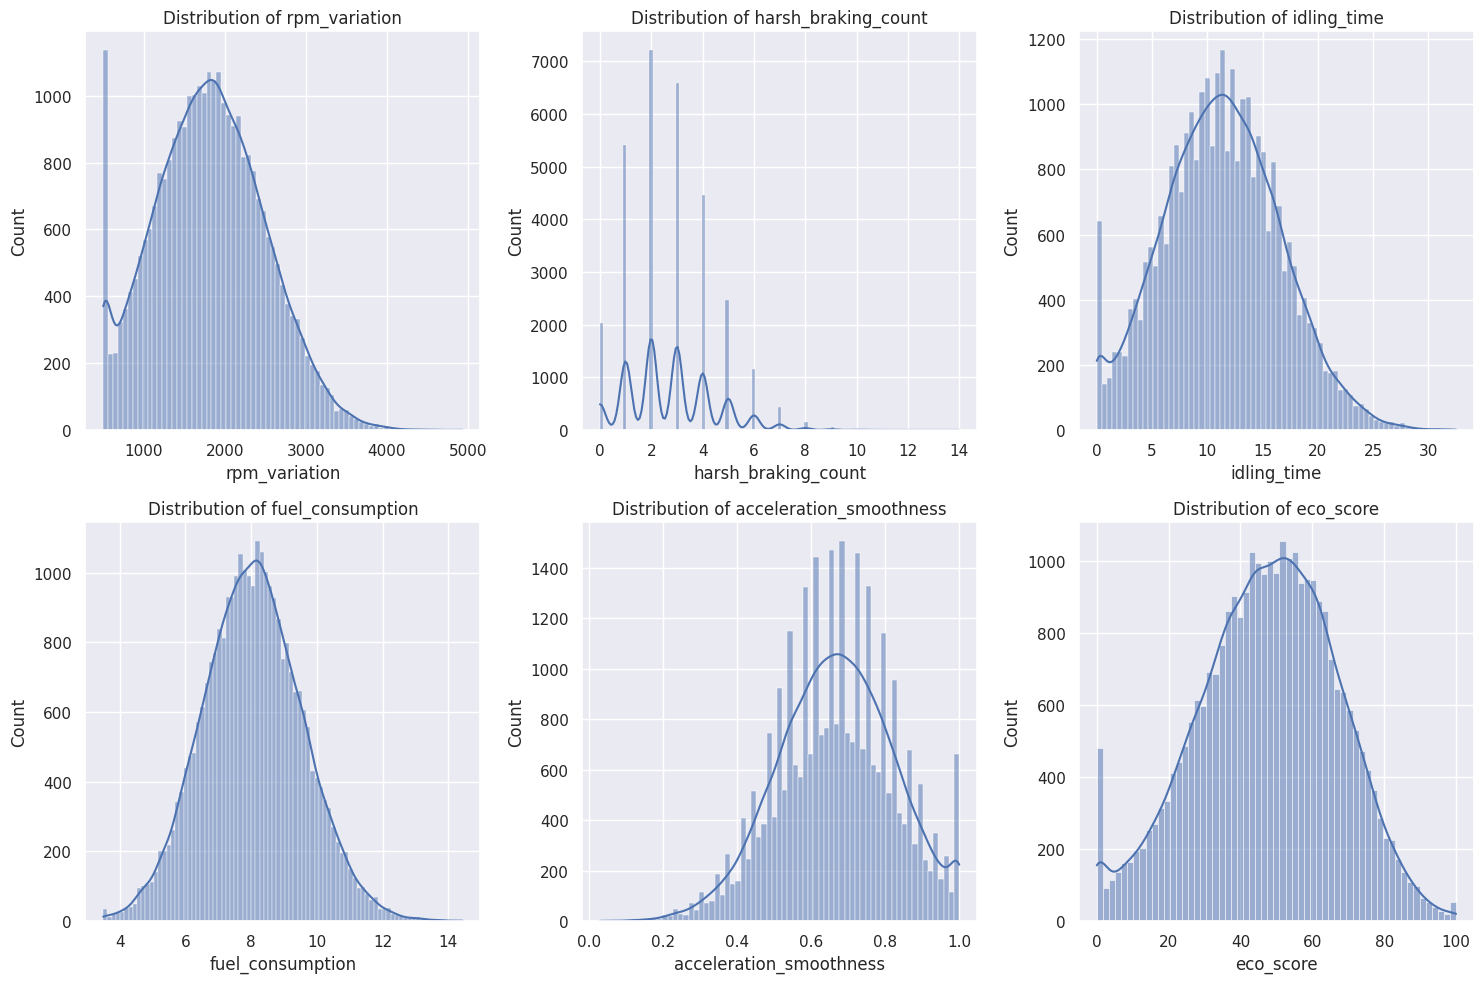


(No categorical columns found in the dataset)


In [25]:
# Univariate Analysis: Distributions of Numerical Features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Plot histograms with KDE in a grid
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Check for categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if not categorical_cols:
    print("\n(No categorical columns found in the dataset)")
else:
    for col in categorical_cols:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col)
        plt.title(f'Distribution of {col}')
        plt.show()

# Bivariate Analysis

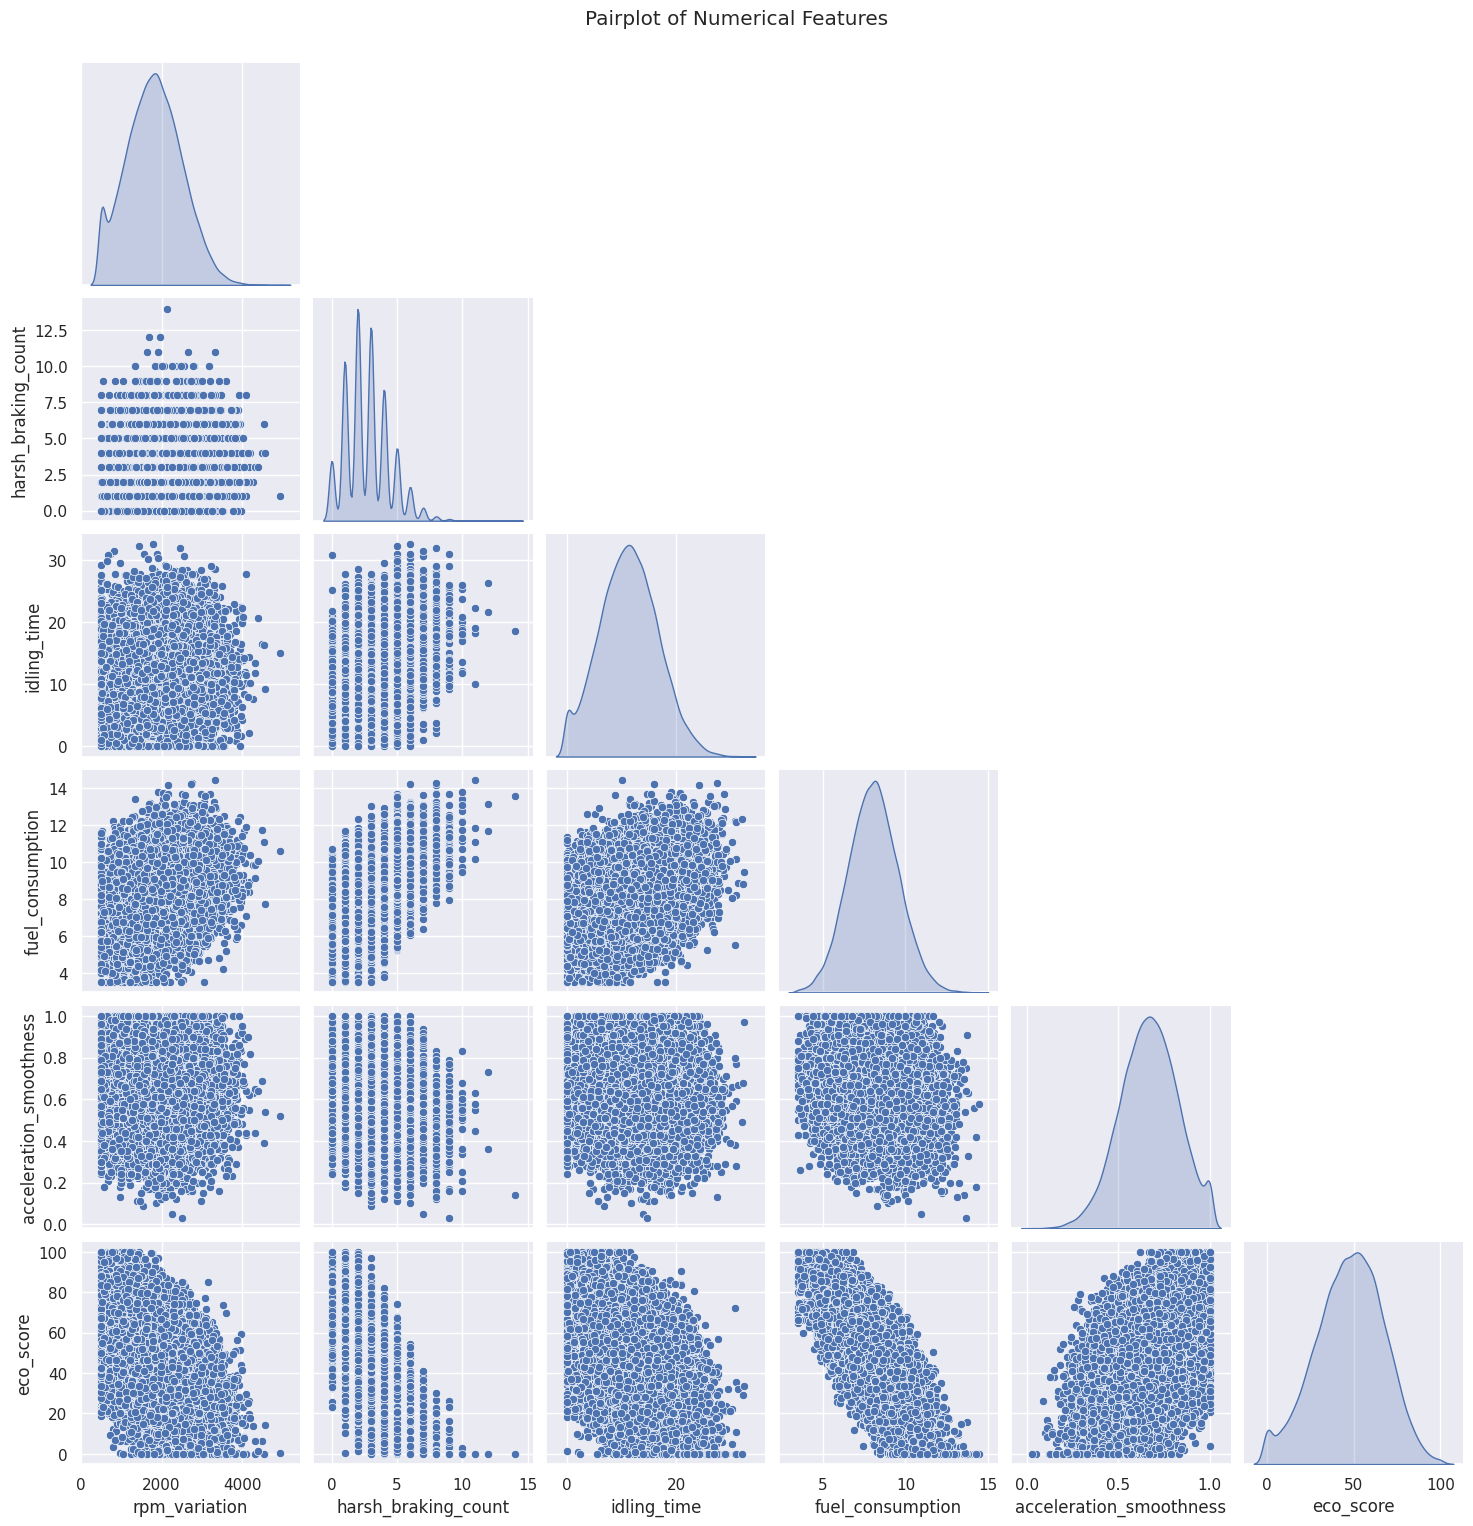

In [26]:
# Bivariate Analysis: Pairplot
# This visualizes the pairwise relationships between all numerical features
sns.pairplot(df.select_dtypes(include=np.number), diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

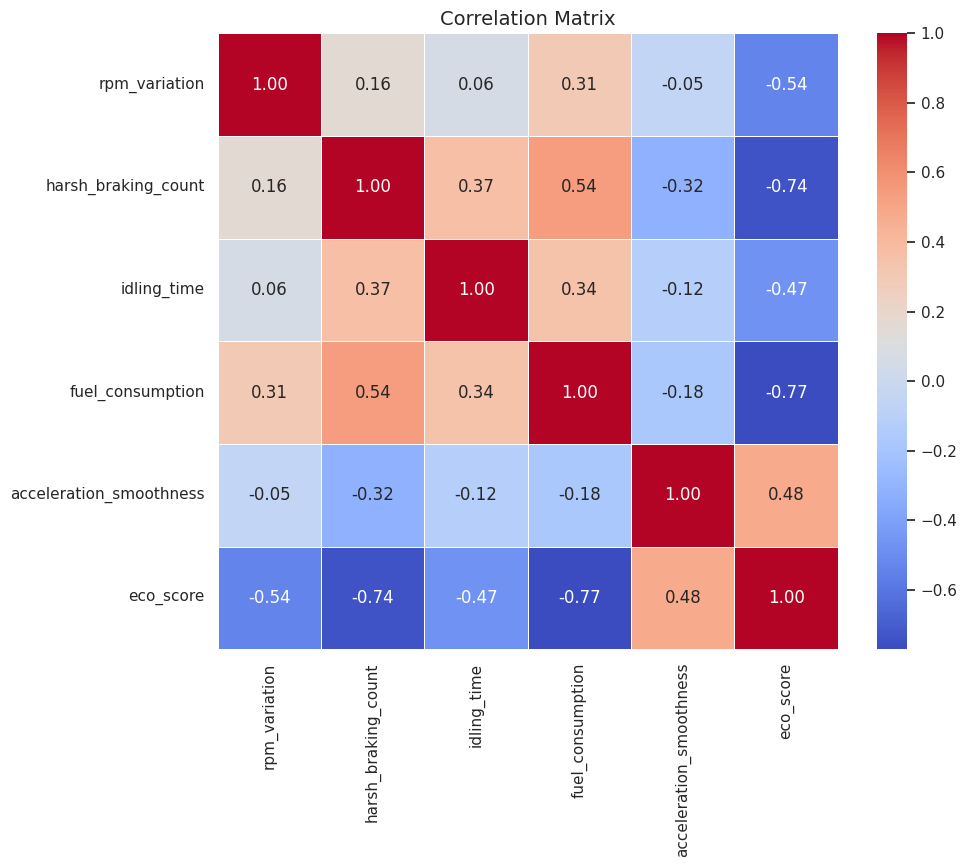

In [28]:
# Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Feature Engineering

In [30]:
df['Log_RPM_Variation'] = np.log1p(df['rpm_variation'])

# Checking the new features
# changed 'Eco_Score' to 'eco_score' to match dataframe
print("Feature engineering complete. Showing 'eco_score' and new 'Log_RPM_Variation':")
print(df[['eco_score', 'Log_RPM_Variation']].head())

Feature engineering complete. Showing 'eco_score' and new 'Log_RPM_Variation':
   eco_score  Log_RPM_Variation
0       42.1           7.672292
1       36.1           7.440734
2       49.8           7.720462
3       27.7           7.961021
4       79.4           7.400621


In [31]:
# Advanced Feature Engineering: Interaction Terms

# 1. Aggressive Score: Combining high RPM variation with harsh braking events
# Normalizing slightly to keep numbers manageable
df['Aggressive_Score'] = (df['rpm_variation'] * df['harsh_braking_count']) / 1000

# 2. Idling to Fuel Ratio: High ratio means fuel is being wasted on idling rather than driving
df['Idling_to_Fuel_Ratio'] = df['idling_time'] / (df['fuel_consumption'] + 0.01) # Adding small epsilon to avoid division by zero

# Let's check the correlation of these new features with the target
new_correlations = df[['eco_score', 'Aggressive_Score', 'Idling_to_Fuel_Ratio', 'Log_RPM_Variation']].corr()
print("Correlation with Eco Score:")
print(new_correlations['eco_score'].sort_values(ascending=False))

Correlation with Eco Score:
eco_score               1.000000
Idling_to_Fuel_Ratio   -0.156554
Log_RPM_Variation      -0.519193
Aggressive_Score       -0.815353
Name: eco_score, dtype: float64


# Unsupervised ( Outlier Detection and Clustering (Segmentation)).

Anomalies Found: 56


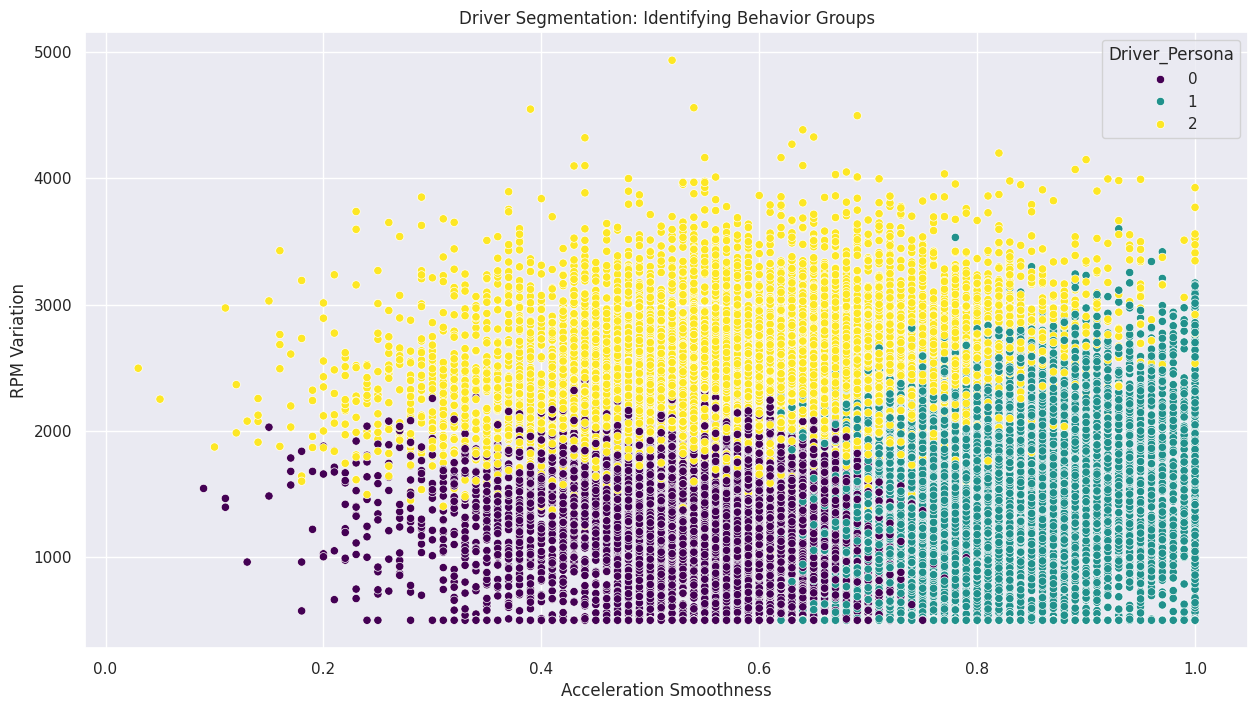

                acceleration_smoothness  rpm_variation  eco_score
Driver_Persona                                                   
0                              0.561938    1348.072157  49.336437
1                              0.810083    1580.491288  63.118553
2                              0.607721    2455.344902  29.111484


In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

# 1. Outlier Detection (Z-Score)
# Find RPM variations that are 3 Standard Deviations away from the mean
# Changed 'RPM' to 'rpm_variation'
df['RPM_Z_Score'] = zscore(df['rpm_variation'])
df['Is_Anomaly'] = df['RPM_Z_Score'].abs() > 3

print(f"Anomalies Found: {df['Is_Anomaly'].sum()}")

# 2. Clustering (K-Means)
# Select features to group by
# Changed columns to match dataset: 'Average_Speed' -> 'acceleration_smoothness', 'RPM' -> 'rpm_variation', 'Eco_Score' -> 'eco_score'
features = df[['acceleration_smoothness', 'rpm_variation', 'eco_score']]

# Scale the data (Clustering requires scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Run K-Means (e.g., 3 Clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Driver_Persona'] = kmeans.fit_predict(X_scaled)

# 3. Visualize the Personas
plt.figure(figsize=(15, 8))
# Changed axes to match selected features
sns.scatterplot(data=df, x='acceleration_smoothness', y='rpm_variation', hue='Driver_Persona', palette='viridis')
plt.title('Driver Segmentation: Identifying Behavior Groups')
plt.xlabel('Acceleration Smoothness')
plt.ylabel('RPM Variation')
plt.show()

# 4. Interpret the Clusters
# Changed columns for interpretation
print(df.groupby('Driver_Persona')[['acceleration_smoothness', 'rpm_variation', 'eco_score']].mean())

# PCA ( Princial Components Analysis )

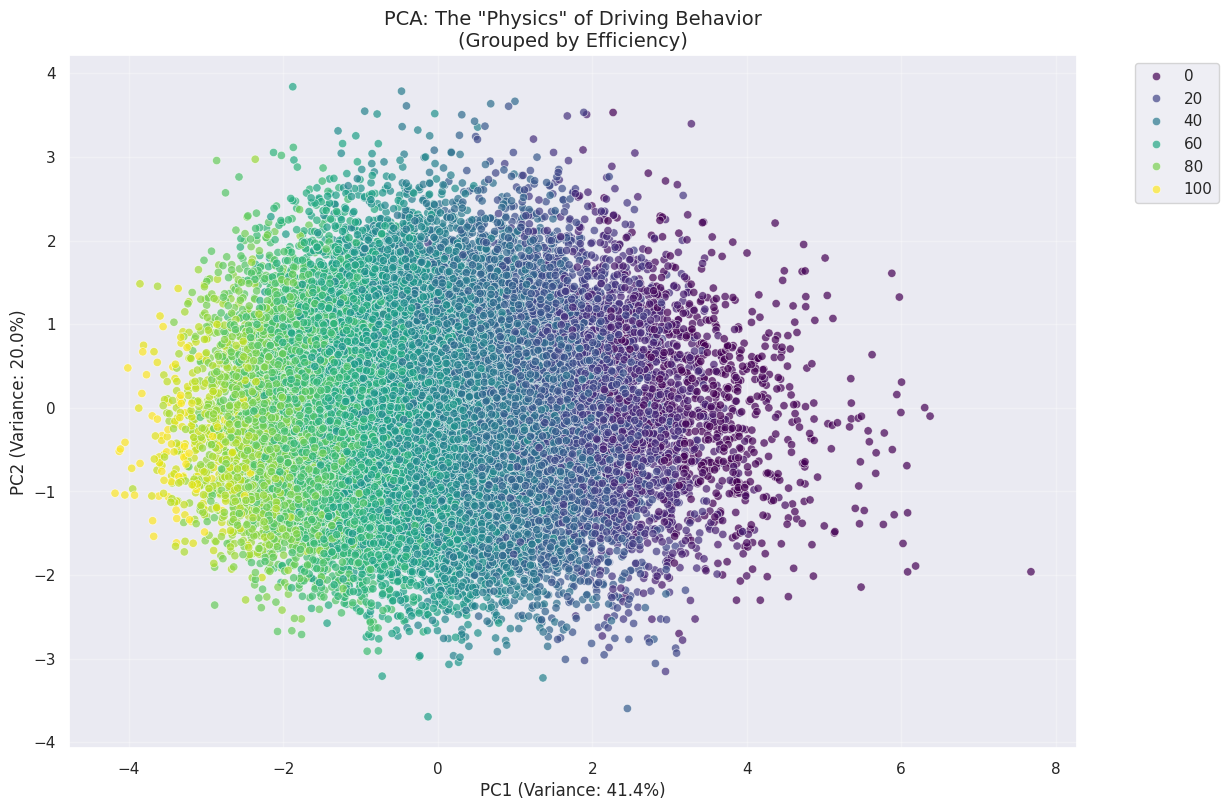

--- What does PC1 represent? (Feature Weights) ---
harsh_braking_count        0.568180
fuel_consumption           0.558279
idling_time                0.425638
rpm_variation              0.284867
acceleration_smoothness   -0.321214
dtype: float64


In [44]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Select Features for PCA (Numerical Only)
# Using available columns instead of missing ones
features = ['acceleration_smoothness', 'rpm_variation', 'fuel_consumption', 'harsh_braking_count', 'idling_time']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# 2. Run PCA (Reduce to 2 Dimensions)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Eco_Score'] = df['eco_score']
# Use 'Driver_Persona' if available, otherwise just use Eco_Score for size/hue
if 'Driver_Persona' in df.columns:
    pca_df['Cluster'] = df['Driver_Persona']

# 3. Visualize the "Driving Universe"
plt.figure(figsize=(13, 9))
# Removing 'Road_Type' as it doesn't exist. Using 'Eco_Score' for hue.
scatter = sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                          hue='Eco_Score', palette='viridis',
                          alpha=0.7)

plt.title('PCA: The "Physics" of Driving Behavior\n(Grouped by Efficiency)', fontsize=14)
plt.xlabel(f'PC1 (Variance: {pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 (Variance: {pca.explained_variance_ratio_[1]:.1%})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Interpret Components
print("--- What does PC1 represent? (Feature Weights) ---")
print(pd.Series(pca.components_[0], index=features).sort_values(ascending=False))

# Machine Learning


--- Starting Machine Learning Model ---
Model Performance:
MAE: 4.31 (Average error in Eco Score points)
R² Score: 92.04% (How much variance we explained)


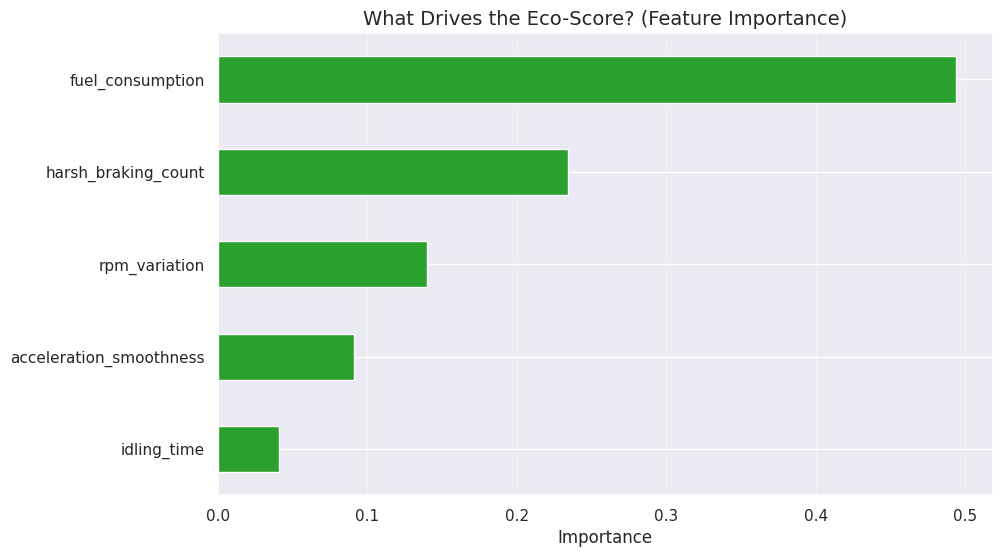

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("\n--- Starting Machine Learning Model ---")

# 1. Defining Features & Target
# Using the columns identified in your PCA step
feature_cols = ['acceleration_smoothness', 'rpm_variation', 'fuel_consumption',
                'harsh_braking_count', 'idling_time']
X = df[feature_cols]
y = df['eco_score']

# 2. Spliting Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluating
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Model Performance:")
print(f"MAE: {mae:.2f} (Average error in Eco Score points)")
print(f"R² Score: {r2:.2%} (How much variance we explained)")

# 5. Visualizing the "Why" (Feature Importance)
# This is the most valuable chart for business insights
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2ca02c')
plt.title('What Drives the Eco-Score? (Feature Importance)', fontsize=14)
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.3)
plt.show()

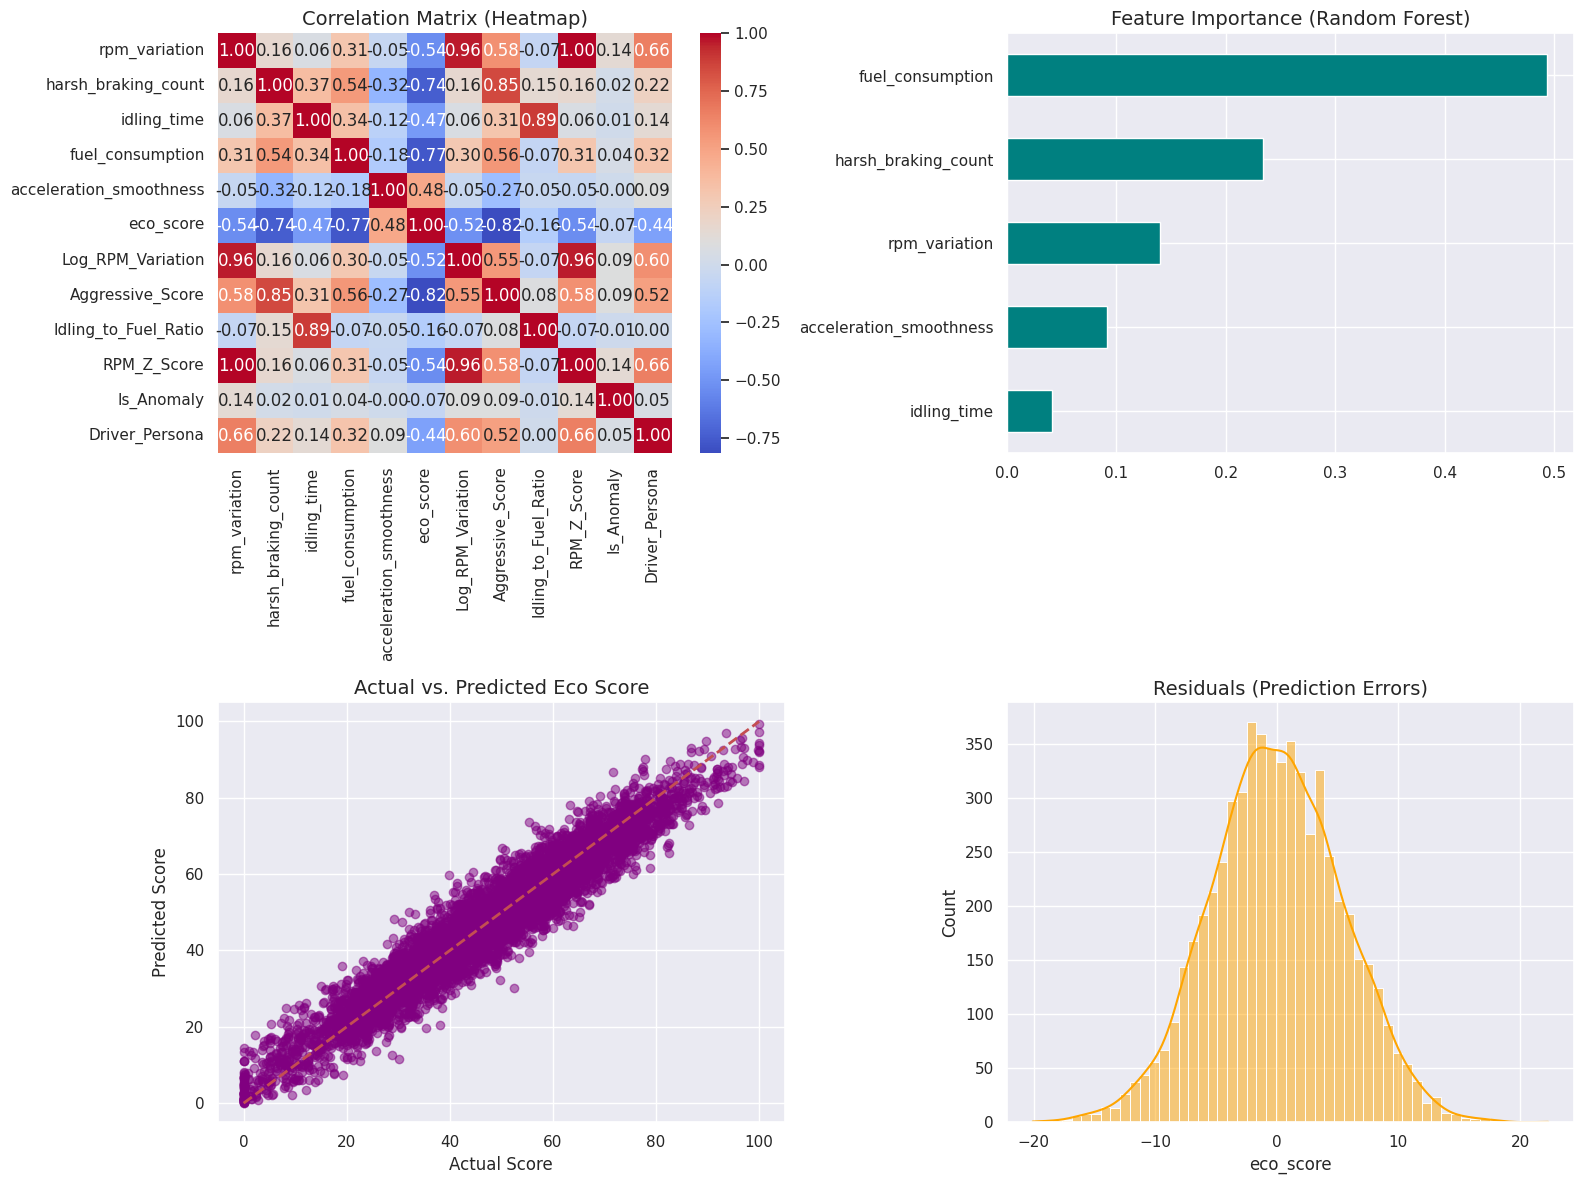


--- Linear Coefficients (Impact per Unit) ---
                   Feature  Coefficient
0  acceleration_smoothness    33.914595
1            rpm_variation    -0.009840
4              idling_time    -0.597462
3      harsh_braking_count    -3.861993
2         fuel_consumption    -4.886686


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# --- BONUS: LINEAR COEFFICIENTS (To answer your specific request) ---
# We fit a quick Linear Model just to get the coefficients you asked for
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})

# --- CREATE PLOTS ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation Matrix (The "Relationship Map")
# This shows how every feature interacts with every other feature
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title('Correlation Matrix (Heatmap)', fontsize=14)

# 2. Feature Importance (Random Forest)
# This shows which features actually drive the prediction in your main model
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='teal', ax=axes[0, 1])
axes[0, 1].set_title('Feature Importance (Random Forest)', fontsize=14)

# 3. Actual vs. Predicted (Performance Check)
# Ideally, all points should be on the red dotted line
preds = model.predict(X_test)
axes[1, 0].scatter(y_test, preds, alpha=0.5, color='purple')
axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1, 0].set_title('Actual vs. Predicted Eco Score', fontsize=14)
axes[1, 0].set_xlabel('Actual Score')
axes[1, 0].set_ylabel('Predicted Score')

# 4. Residual Plot (Error Check)
# Shows the distribution of errors. Should be a bell curve centered at 0.
residuals = y_test - preds
sns.histplot(residuals, kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('Residuals (Prediction Errors)', fontsize=14)

plt.tight_layout()
plt.show()

# Print the Linear Coefficients table for reference
print("\n--- Linear Coefficients (Impact per Unit) ---")
print(coef_df.sort_values('Coefficient', ascending=False))

# Thank You